#Library and File Importation

In [ ]:
%matplotlib inline
# ===============================
# IMPORT ALL NECESSARY LIBRARIES
# ===============================
# --- Data manipulation ---
import pandas as pd
import numpy as np
# --- File handling (Colab upload, zip) ---
from google.colab import files
import zipfile, io, glob, os
import joblib
# --- Preprocessing ---
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
# --- Machine learning models ---
from sklearn.ensemble import RandomForestClassifier
# --- Model evaluation ---
import time
import psutil
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
# --- Misc / warnings ---
import warnings
warnings.filterwarnings("ignore")

files.upload()
import os
os.listdir()

Saving NSL-KDD(testing) - KDDTest+.csv to NSL-KDD(testing) - KDDTest+.csv
Saving NSL-KDD(training) - KDDTrain+.csv to NSL-KDD(training) - KDDTrain+.csv
Saving UNSW-NB15 (testing) - UNSW_NB15_testing-set (1).csv to UNSW-NB15 (testing) - UNSW_NB15_testing-set (1).csv
Saving UNSW-NB15 (training) - UNSW_NB15_training-set (1).csv to UNSW-NB15 (training) - UNSW_NB15_training-set (1).csv


['.config',
 'UNSW-NB15 (testing) - UNSW_NB15_testing-set (1).csv',
 'NSL-KDD(training) - KDDTrain+.csv',
 'UNSW-NB15 (training) - UNSW_NB15_training-set (1).csv',
 'NSL-KDD(testing) - KDDTest+.csv',
 'sample_data']

In [ ]:
# ==== Upload ZIP file ====
uploaded = files.upload()
# ==== Unzip file ====
zip_name = list(uploaded.keys())[0]

with zipfile.ZipFile(io.BytesIO(uploaded[zip_name]), 'r') as zip_ref:
    zip_ref.extractall('/content/cic_data')

# ==== Load all CSVs with chunk loading ====
csv_files = glob.glob('/content/cic_data/**/*.csv', recursive=True)

cic_ids_df_list = []
for file in csv_files:
    print(f"Loading {os.path.basename(file)}")

    chunks = pd.read_csv(file, chunksize=100000, low_memory=False)
    temp_cic_ids_df = pd.concat(chunks, ignore_index=True)

    cic_ids_df_list.append(temp_cic_ids_df)

# ==== Combine all files ====
cic_ids_df = pd.concat(cic_ids_df_list, ignore_index=True)

# ==== Clean CIC dataset issues ====
cic_ids_df.columns = cic_ids_df.columns.str.strip()               # remove trailing spaces
cic_ids_df.replace([np.inf, -np.inf], np.nan, inplace=True)
cic_ids_df.dropna(inplace=True)

# ==== Done ====
print("Final shape:", cic_ids_df.shape)
cic_ids_df.head()
cic_ids_df.head()

Saving MachineLearningCSV.zip to MachineLearningCSV.zip
Loading Monday-WorkingHours.pcap_ISCX.csv
Loading Tuesday-WorkingHours.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading Wednesday-workingHours.pcap_ISCX.csv
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Final shape: (2827876, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,49188,4,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,49188,1,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,49486,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


# Data Preprocessing



In [ ]:
# ==============================
# === Data Preprocessing ===
# ==============================
# ------------------------------
# Load NSL-KDD
# ------------------------------
nsl_train = pd.read_csv("NSL-KDD(training) - KDDTrain+.csv", header=None)
nsl_test  = pd.read_csv("NSL-KDD(testing) - KDDTest+.csv", header=None)
nsl = pd.concat([nsl_train, nsl_test], ignore_index=True)
nsl.rename(columns={41: "attack_type"}, inplace=True)
nsl["dataset"] = "NSL-KDD"

# ------------------------------
# Load UNSW-NB15
# ------------------------------
unsw_train = pd.read_csv("UNSW-NB15 (training) - UNSW_NB15_training-set (1).csv")
unsw_test  = pd.read_csv("UNSW-NB15 (testing) - UNSW_NB15_testing-set (1).csv")
unsw = pd.concat([unsw_train, unsw_test], ignore_index=True)
unsw.rename(columns={"label": "attack_type"}, inplace=True)
unsw["dataset"] = "UNSW-NB15"

# ------------------------------
# Combine with CIC-IDS (assuming cic_ids_df already loaded)
# ------------------------------
combined_df = pd.concat([nsl, unsw, cic_ids_df], ignore_index=True)
print("Original dataset size:", combined_df.shape)

# ------------------------------
# Safe sampling to prevent RAM crash
# ------------------------------
combined_df = combined_df.sample(min(200_000, len(combined_df)), random_state=42)
print("Sampled dataset size:", combined_df.shape)

# ------------------------------
# Basic cleaning
# ------------------------------
combined_df.replace([np.inf, -np.inf], np.nan, inplace=True)
combined_df = combined_df.dropna(subset=["attack_type"])
combined_df.fillna(0, inplace=True)
combined_df.drop_duplicates(inplace=True)

# ------------------------------
# Reduce RAM usage
# ------------------------------
for col in combined_df.select_dtypes(include=["float64"]).columns:
    combined_df[col] = combined_df[col].astype("float32")
for col in combined_df.select_dtypes(include=["int64"]).columns:
    combined_df[col] = combined_df[col].astype("int32")

# ------------------------------
# Remove leak / useless columns
# ------------------------------
drop_cols = [c for c in combined_df.columns if
             "Flow ID" in str(c) or
             "Source IP" in str(c) or
             "Destination IP" in str(c) or
             "Timestamp" in str(c)]
combined_df.drop(columns=drop_cols, inplace=True, errors="ignore")

# ------------------------------
# Feature engineering
# ------------------------------
if {"Flow Duration", "Total Fwd Packets", "Total Backward Packets"}.issubset(combined_df.columns):
    total_packets = combined_df["Total Fwd Packets"] + combined_df["Total Backward Packets"]
    combined_df["packet_rate"] = total_packets / combined_df["Flow Duration"].replace(0, 1)

# ------------------------------
# Create labels
# ------------------------------
combined_df["binary_label"] = combined_df["attack_type"].apply(
    lambda x: 0 if str(x).upper() in ["NORMAL", "BENIGN"] else 1
)
combined_df["multi_label"] = combined_df["attack_type"].astype(str)

# ------------------------------
# Encode categorical features safely
# ------------------------------
cat_cols = combined_df.select_dtypes(include=["object"]).columns
for col in cat_cols:
    if col in ["attack_type", "multi_label"]:
        continue
    combined_df[col] = combined_df[col].astype(str)
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col])

# ------------------------------
# Split features and labels
# ------------------------------
X = combined_df.drop(columns=["binary_label", "multi_label", "attack_type", 'Label', 'attack_cat', 'dataset', 'Destination Port'], errors="ignore")
X.columns = X.columns.astype(str)
y_binary = combined_df["binary_label"]
y_multi = combined_df["multi_label"]

print("Dataset ready. Shape:", X.shape)

# ------------------------------
# Train/Test split
# ------------------------------
X_train, X_test, y_bin_train, y_bin_test, y_multi_train, y_multi_test = train_test_split(
    X,
    y_binary,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# ------------------------------
# Feature scaling
# ------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Preprocessing complete. X_train shape:", X_train.shape, "X_test shape:", X_test.shape)



Original dataset size: (3234066, 158)
Sampled dataset size: (200000, 158)
Dataset ready. Shape: (20706, 154)
Preprocessing complete. X_train shape: (16564, 154) X_test shape: (4142, 154)


# Train Classification Models




In [ ]:
# ==============================
# === Training Classification Models ===
# ==============================

print("=== Training Models ===")

# ------------------------------
# Binary Classification SMOTE
# ------------------------------
print("\n--- Binary Classification ---")

# Apply SMOTE only to binary labels
smote_bin = SMOTE(random_state=42)
X_train_bin, y_bin_train_bal = smote_bin.fit_resample(X_train, y_bin_train)

print("Binary SMOTE applied. Balanced class counts:")
print(pd.Series(y_bin_train_bal).value_counts())

# Train Random Forest for binary classification
binary_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
binary_model.fit(X_train_bin, y_bin_train_bal)
print("Binary model trained.")

# ------------------------------
# Multi-Class Classification (safe)
# ------------------------------
print("\n--- Multi-Class Classification ---")

# Only keep classes with enough samples to avoid SMOTE errors
min_class_count = 6  # must be >= n_neighbors for SMOTE default
class_counts = y_multi_train.value_counts()
valid_classes = class_counts[class_counts >= min_class_count].index.tolist()

# Filter training data to only valid classes
mask = y_multi_train.isin(valid_classes)
X_train_multi = X_train[mask]
y_multi_train_filtered = y_multi_train[mask]

print(f"Training multi-class on {len(valid_classes)} classes (classes with >= {min_class_count} samples).")

# Apply SMOTE
smote_multi = SMOTE(random_state=42)
X_train_multi_bal, y_multi_train_bal = smote_multi.fit_resample(X_train_multi, y_multi_train_filtered)

print("Multi-class SMOTE applied. Balanced class counts:")
print(pd.Series(y_multi_train_bal).value_counts())

# Train Random Forest for multi-class classification
multi_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
multi_model.fit(X_train_multi_bal, y_multi_train_bal)
print("Multi-class model trained.")

=== Training Models ===

--- Binary Classification ---
Binary SMOTE applied. Balanced class counts:
binary_label
1    12771
0    12771
Name: count, dtype: int64
Binary model trained.

--- Multi-Class Classification ---
Training multi-class on 23 classes (classes with >= 6 samples).
Multi-class SMOTE applied. Balanced class counts:
multi_label
1                4875
neptune          4875
normal           4875
0                4875
warezmaster      4875
mscan            4875
smurf            4875
satan            4875
guess_passwd     4875
nmap             4875
portsweep        4875
back             4875
ipsweep          4875
pod              4875
processtable     4875
apache2          4875
mailbomb         4875
warezclient      4875
teardrop         4875
httptunnel       4875
snmpgetattack    4875
snmpguess        4875
saint            4875
Name: count, dtype: int64
Multi-class model trained.


# Evaluate Model Performance




In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np

# ==============================
# === Evaluate Model Performance (with FPR) ===
# ==============================
def evaluate_model(model, X_test, y_test, dataset_name="Dataset", binary=False):
    """Evaluates model performance and prints metrics, including FPR."""

    # Predict
    y_pred = model.predict(X_test)

    # Compute standard metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1        = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Compute False Positive Rate
    if binary:
        # Binary classification
        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
        fpr = fp / (fp + tn)
        fpr_str = f"{fpr*100:.2f}%"
    else:
        # Multi-class classification: average FPR
        classes = np.unique(y_test)
        fpr_list = []
        for cls in classes:
            y_test_bin = (y_test == cls).astype(int)
            y_pred_bin = (y_pred == cls).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_test_bin, y_pred_bin).ravel()
            fpr_list.append(fp / (fp + tn))
        fpr = np.mean(fpr_list)
        fpr_str = f"{fpr*100:.2f}% (average)"

    # Print results
    print(f"\n--- {dataset_name} Model Performance ---")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"FPR      : {fpr_str}")

    return accuracy, precision, recall, f1, fpr

# ------------------------------
# Evaluate Binary Model
# ------------------------------
evaluate_model(binary_model, X_test, y_bin_test, dataset_name="Binary Classification", binary=True)

# ------------------------------
# Evaluate Multi-Class Model
# ------------------------------
# Filter test set to only classes present in training
valid_classes = y_multi_train_bal.unique()
mask = y_multi_test.isin(valid_classes)
X_test_multi = X_test[mask]
y_multi_test_filtered = y_multi_test[mask]

evaluate_model(multi_model, X_test_multi, y_multi_test_filtered, dataset_name="Multi-Class Classification", binary=False)
# ----------------------------
# SETTINGS (Replace with your models and datasets)
# ----------------------------

# Binary model
binary_model = binary_model        # your trained binary model
X_test_bin = X_test         # test features for binary model
y_test_bin = y_bin_test            # true labels for binary model
binary_model_file = "binary_model.pkl"  # file path if saved

# Multi-class attack model
multi_model = multi_model    # your trained multi-class model
X_test_multi = X_test_multi        # test features for multi-class model
y_test_multi = y_multi_test_filtered      # true labels for multi-class model
multi_model_file = "multi_model.pkl"    # file path if saved
# ----------------------------
# FUNCTION TO MEASURE LATENCY, CPU, RAM
# ----------------------------
def measure_performance(model, X_test):
    latencies = []
    cpu_percentages = []
    mem_before = psutil.virtual_memory().used / (1024*1024)  # MB

    for i in range(len(X_test)):
        # Handle both DataFrame and ndarray
        if isinstance(X_test, np.ndarray):
            packet = X_test[i].reshape(1, -1)
        else:  # DataFrame
            packet = X_test.iloc[i].values.reshape(1, -1)

        start = time.perf_counter()
        psutil.cpu_percent(interval=None)  # reset
        model.predict(packet)
        end = time.perf_counter()

        latencies.append(end - start)
        cpu_percentages.append(psutil.cpu_percent(interval=None))

    mem_after = psutil.virtual_memory().used / (1024*1024)
    avg_latency_ms = np.mean(latencies) * 1000
    avg_cpu = np.mean(cpu_percentages)
    ram_used = mem_after - mem_before

    return avg_latency_ms, avg_cpu, ram_used
print(len(y_multi_test_filtered))
print(len(y_bin_test))

# ----------------------------
# FUNCTION TO CALCULATE PER-CLASS RECALL
# ----------------------------
def get_per_class_recall(model, X_test, y_test):
    y_pred = model.predict(X_test)
    recall_vals = recall_score(y_test, y_pred, average=None)
    classes = sorted(list(set(y_test)))
    recall_dict = {cls: val*100 for cls, val in zip(classes, recall_vals)}
    return recall_dict

# ----------------------------
# FUNCTION TO GET MODEL SIZE
# ----------------------------
def get_model_size(file_path):
    if os.path.exists(file_path):
        return os.path.getsize(file_path) / (1024*1024)  # MB
    else:
        return None


# ----------------------------
# RUN FOR BINARY MODEL
# ----------------------------
lat_bin, cpu_bin, ram_bin = measure_performance(binary_model, X_test_bin)
recall_bin = get_per_class_recall(binary_model, X_test_bin, y_test_bin)
size_bin = get_model_size(binary_model_file)
# Print Binary Table
print("\n===== Binary Model Performance =====")
print(f"{'Metric':<25}{'Value'}")
print(f"{'-'*40}")
print(f"{'Average Latency (ms)':<25}{lat_bin:.2f}")
print(f"{'CPU Usage (%)':<25}{cpu_bin:.2f}")
print(f"{'RAM Usage (MB)':<25}{ram_bin:.2f}")
print(f"{'Model Size (MB)':<25}{size_bin if size_bin else 'File not found'}")
for cls, val in recall_bin.items():
    print(f"Recall ({cls}):{'':<15}{val:.2f}%")

# ----------------------------
# RUN FOR MULTI-CLASS MODEL
# ----------------------------
lat_multi, cpu_multi, ram_multi = measure_performance(multi_model, X_test_multi)
recall_multi = get_per_class_recall(multi_model, X_test_multi, y_test_multi)
size_multi = get_model_size(multi_model_file)

# Print Multi-Class Table
print("\n===== Multi-Class Model Performance =====")
print(f"{'Metric':<25}{'Value'}")
print(f"{'-'*40}")
print(f"{'Average Latency (ms)':<25}{lat_multi:.2f}")
print(f"{'CPU Usage (%)':<25}{cpu_multi:.2f}")
print(f"{'RAM Usage (MB)':<25}{ram_multi:.2f}")
print(f"{'Model Size (MB)':<25}{size_multi if size_multi else 'File not found'}")
for cls, val in recall_multi.items():
    print(f"Recall ({cls}):{'':<15}{val:.2f}%")


--- Binary Classification Model Performance ---
Accuracy : 0.9983
Precision: 0.9983
Recall   : 0.9983
F1-score : 0.9983
FPR      : 0.21%

--- Multi-Class Classification Model Performance ---
Accuracy : 0.9415
Precision: 0.9416
Recall   : 0.9415
F1-score : 0.9415
FPR      : 0.37% (average)
4138
4142

===== Binary Model Performance =====
Metric                   Value
----------------------------------------
Average Latency (ms)     43.79
CPU Usage (%)            55.11
RAM Usage (MB)           2.87
Model Size (MB)          File not found
Recall (0):               99.79%
Recall (1):               99.84%

===== Multi-Class Model Performance =====
Metric                   Value
----------------------------------------
Average Latency (ms)     43.41
CPU Usage (%)            54.18
RAM Usage (MB)           -23.35
Model Size (MB)          File not found
Recall (0):               88.70%
Recall (1):               91.32%
Recall (apache2):               100.00%
Recall (back):               100.00%

# Visualization of Threat Detection Results

##Confusion Matrix

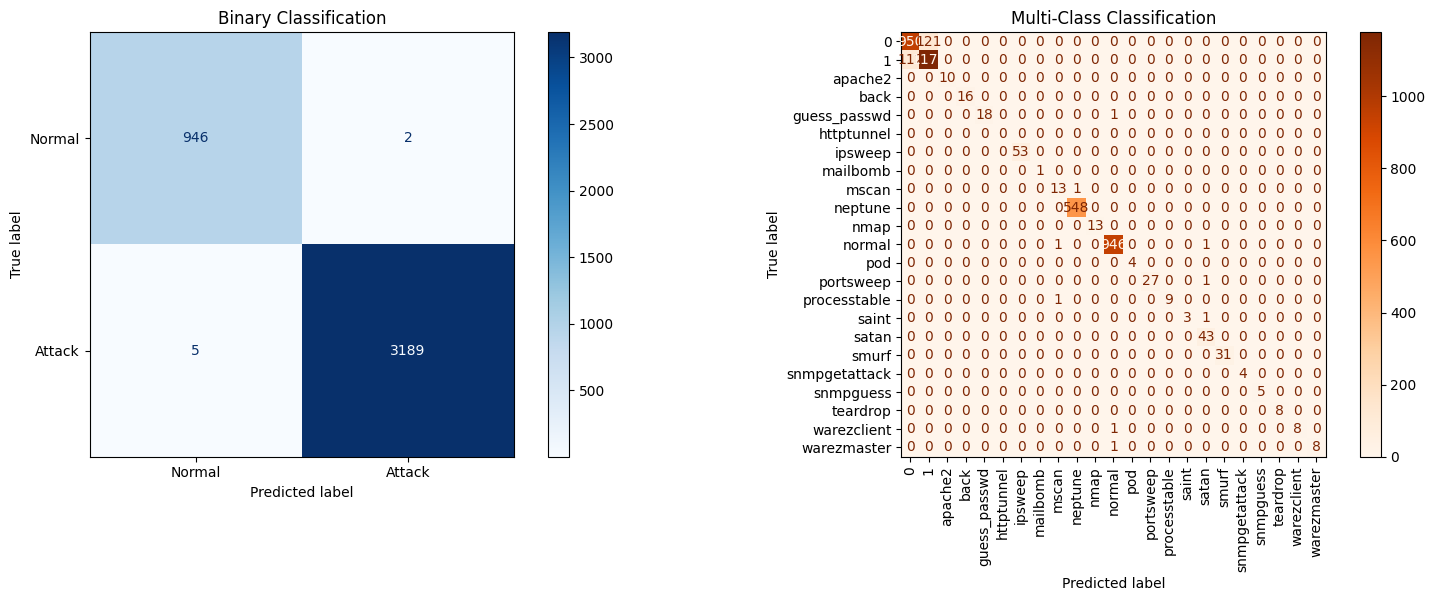

(20706, 154)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Models saved successfully


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

159


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '42', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean

In [ ]:
# ==============================
# === Confusion Matrix Visualization ===
# ==============================


# ------------------------------
# Binary classification
# ------------------------------
y_bin_pred = binary_model.predict(X_test)

cm_bin = confusion_matrix(y_bin_test, y_bin_pred)
disp_bin = ConfusionMatrixDisplay(cm_bin, display_labels=["Normal", "Attack"])

# ------------------------------
# Multi-class classification
# ------------------------------
y_multi_pred = multi_model.predict(X_test_multi)

# Use only the classes seen in training
classes_multi = np.unique(y_multi_train_filtered)
cm_multi = confusion_matrix(y_multi_test_filtered, y_multi_pred, labels=classes_multi)
disp_multi = ConfusionMatrixDisplay(cm_multi, display_labels=classes_multi)

# ------------------------------
# Plot side by side
# ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16,6))

disp_bin.plot(ax=axes[0], cmap=plt.cm.Blues)
axes[0].set_title("Binary Classification")

disp_multi.plot(ax=axes[1], cmap=plt.cm.Oranges, xticks_rotation=90)
axes[1].set_title("Multi-Class Classification")

plt.tight_layout()
plt.show()

print(X.shape)
X.to_csv("simulation_test.csv", index=False)
files.download("simulation_test.csv")


joblib.dump(binary_model, "binary_model.pkl")
joblib.dump(multi_model, "class_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "labelEncoder.pkl")
print("Models saved successfully")

files.download("binary_model.pkl")
files.download("class_model.pkl")
files.download("scaler.pkl")
files.download("labelEncoder.pkl")


numeric_df = combined_df.select_dtypes(include=[np.number])
print(len(numeric_df.columns))

# Compute median and mean safely
feature_medians = numeric_df.median()
np.save("feature_medians.npy", feature_medians.values)  # save as NumPy array
files.download("feature_medians.npy")
print(len(numeric_df.columns))
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")
files.download("feature_columns.pkl")
print(feature_columns)
print(feature_columns)



##ROC-AUC Curve

=== Evaluating Models ===

--- Binary Classification ---


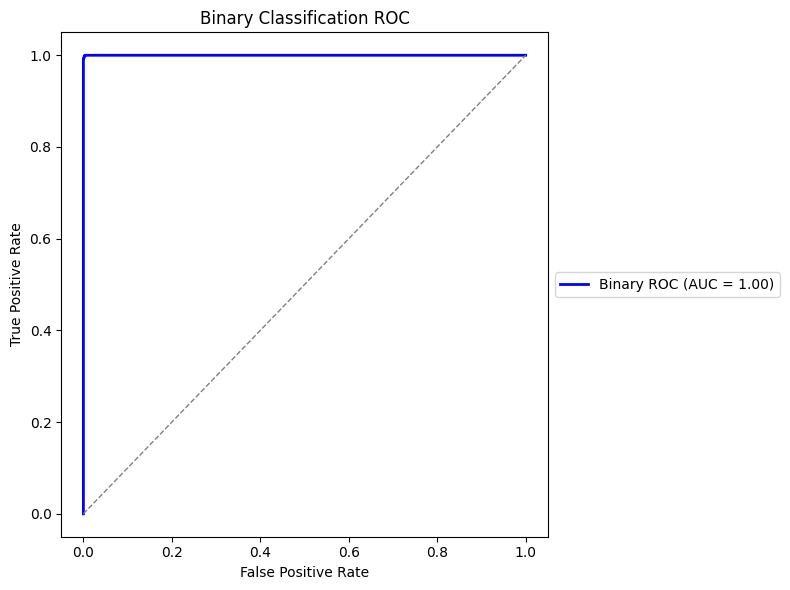


--- Multi-Class Classification (Top 10 Attack Classes) ---
Top 10 attack classes by AUC (excluding 0,1,'normal','httptunnel'): ['apache2', 'back', 'ipsweep', 'mailbomb', 'nmap', 'pod', 'portsweep', 'processtable', 'smurf', 'snmpgetattack']


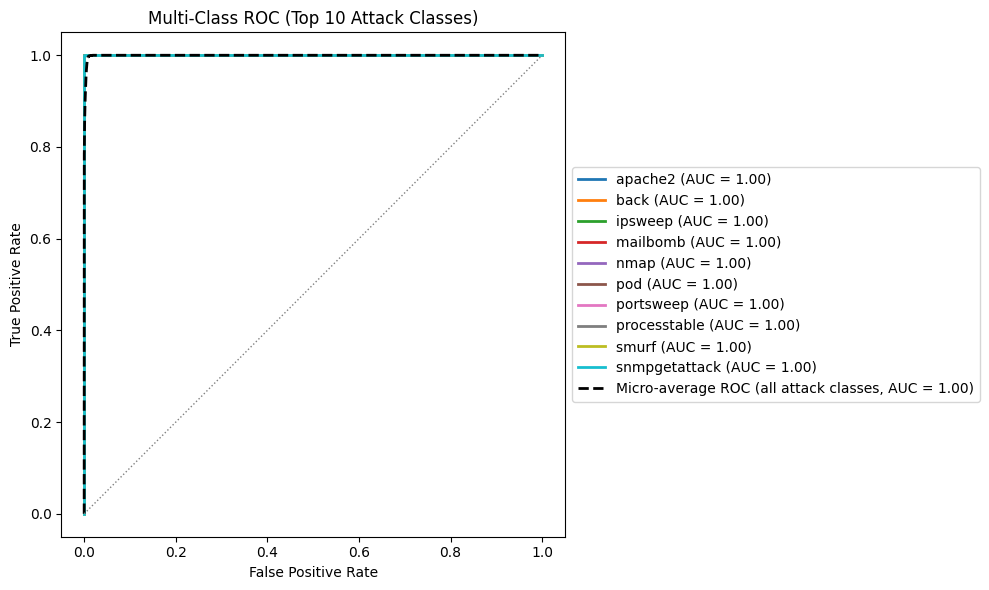

Macro-average AUC (top 10 attack classes): 1.00
Micro-average AUC (all attack classes excluding 0,1,'normal','httptunnel'): 1.00


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# === Evaluate Models with ROC (Top 10 Attack Classes, Exclude 0,1,'normal','httptunnel') ===
# ==============================

print("=== Evaluating Models ===")

# ------------------------------
# Binary Classification
# ------------------------------
print("\n--- Binary Classification ---")
y_bin_probs = binary_model.predict_proba(X_test)[:, 1]  # probability for positive class

fpr_bin, tpr_bin, _ = roc_curve(y_bin_test, y_bin_probs)
roc_auc_bin = auc(fpr_bin, tpr_bin)

plt.figure(figsize=(8, 6))
plt.plot(fpr_bin, tpr_bin, color='blue', lw=2, label=f'Binary ROC (AUC = {roc_auc_bin:.2f})')
plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Binary Classification ROC")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

# ------------------------------
# Multi-Class Classification (Top 10 Attack Classes)
# ------------------------------
print("\n--- Multi-Class Classification (Top 10 Attack Classes) ---")

# Exclude normal and problematic classes
exclude_classes = [0, 1, 'normal', 'httptunnel']
attack_classes = [c for c in multi_model.classes_ if c not in exclude_classes]

# Binarize test labels for remaining attack classes
y_multi_test_bin_all = label_binarize(y_multi_test, classes=attack_classes)

# Predict probabilities for all classes
y_multi_probs_full = multi_model.predict_proba(X_test)
attack_indices = [i for i, c in enumerate(multi_model.classes_) if c in attack_classes]
y_multi_probs_all = y_multi_probs_full[:, attack_indices]

# Compute per-class AUC
roc_auc_dict = {}
for i, class_label in enumerate(attack_classes):
    fpr, tpr, _ = roc_curve(y_multi_test_bin_all[:, i], y_multi_probs_all[:, i])
    roc_auc_dict[class_label] = auc(fpr, tpr)

# Select top 10 classes by AUC
top_classes = sorted(roc_auc_dict, key=roc_auc_dict.get, reverse=True)[:10]
print(f"Top 10 attack classes by AUC (excluding 0,1,'normal','httptunnel'): {top_classes}")

# Plot ROC for top 10 classes
plt.figure(figsize=(10, 6))
for class_label in top_classes:
    i = attack_classes.index(class_label)
    fpr, tpr, _ = roc_curve(y_multi_test_bin_all[:, i], y_multi_probs_all[:, i])
    roc_auc = roc_auc_dict[class_label]
    plt.plot(fpr, tpr, lw=2, label=f"{class_label} (AUC = {roc_auc:.2f})")

# Micro-average ROC for all remaining attack classes
fpr_micro, tpr_micro, _ = roc_curve(y_multi_test_bin_all.ravel(), y_multi_probs_all.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

# Macro-average ROC AUC for top 10 classes
roc_auc_macro = np.mean([roc_auc_dict[c] for c in top_classes])

plt.plot(fpr_micro, tpr_micro, color='black', lw=2, linestyle='--', label=f'Micro-average ROC (all attack classes, AUC = {roc_auc_micro:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC (Top 10 Attack Classes)")

# Move legend to the right
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

print(f"Macro-average AUC (top 10 attack classes): {roc_auc_macro:.2f}")
print(f"Micro-average AUC (all attack classes excluding 0,1,'normal','httptunnel'): {roc_auc_micro:.2f}")